<a href="https://colab.research.google.com/github/DeepanshuSharma1607/langgraph/blob/main/lg_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
!pip install uv
!uv pip install langchain-mistralai
!uv pip install langchain-tavily
!uv pip install langchain-community[all]
!uv pip install Wikipedia
!uv pip install langchain-community
!uv pip install wikipedia langchain-community


Using Python 3.12.13 environment at: /usr
Checked 1 package in 155ms
Using Python 3.12.13 environment at: /usr
Checked 1 package in 130ms
Using Python 3.12.13 environment at: /usr
Checked 1 package in 126ms
Using Python 3.12.13 environment at: /usr
Checked 1 package in 97ms
Using Python 3.12.13 environment at: /usr
Checked 1 package in 86ms
Using Python 3.12.13 environment at: /usr
Checked 2 packages in 116ms


In [63]:
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage
)
from langgraph.graph import StateGraph , MessagesState , START , END , add_messages
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display , Image
import requests
from rich import print
from pprint import pprint
from langchain.tools import tool
from typing import TypedDict
from operator import add
from typing import Annotated , List
from pydantic import BaseModel , Field

In [64]:
CHAT_MISTRAL_API_KEY = ""

In [65]:
llm = ChatMistralAI(
    model="mistral-small-2506",
    api_key= CHAT_MISTRAL_API_KEY,
    temperature = 0
)
print(llm.invoke("hello"))

AIMessage(
    content='Hello! 😊 How can I assist you today?',
    additional_kwargs={},
    response_metadata={
        'token_usage': {
            'prompt_tokens': 4,
            'total_tokens': 17,
            'completion_tokens': 13,
            'prompt_tokens_details': {'cached_tokens': 0}
        },
        'model_name': 'mistral-small-2506',
        'model': 'mistral-small-2506',
        'finish_reason': 'stop',
        'model_provider': 'mistralai'
    },
    id='lc_run--019f551f-b2eb-7651-8a32-38245b987bc2-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 4, 'output_tokens': 13, 'total_tokens': 17}
)

In [66]:
from langchain_tavily import TavilySearch
import os
os.environ["TAVILY_API_KEY"] = ""
tavily = TavilySearch(max_results=3)

res = tavily.invoke({"query": "who is ronaldo"})
print(res)

{
    'query': 'who is ronaldo',
    'follow_up_questions': None,
    'answer': None,
    'images': [],
    'results': [
        {
            'url': 
'https://www.realmadrid.com/en-US/the-club/history/football-legends/cristiano-ronaldo-dos-santos-aveiro',
            'title': 'Cristiano Ronaldo Dos Santos Aveiro - History and honours',
            'content': "# Cristiano Ronaldo. Cristiano Ronaldo is a part of Real Madrid's legacy and will forever 
be remember as one of the great icons throughout the club's history. During the course of his nine seasons as a 
Real Madrid player, Ronaldo secured a number of impressive records: the club's all-time leading goalscorer, the 
leading marksmen in European Cup history (he scored 105 goals for Real Madrid in the Champions League); the 
all-time leading madridista goalscorer in LaLiga (312); highest number of games in which a player has scored three 
or more times in LaLiga history (34); and the most goals to have been scored by a Real Madrid player in a single 
season (61).",
            'score': 0.73299384,
            'raw_content': None
        },
        {
            'url': 'https://www.olympics.com/en/athletes/cristiano-ronaldo-dos-santos-aveiro',
            'title': 'Cristiano Ronaldo Biography, Records, Teams, Titles Won, and Age',
            'content': "# Cristiano Ronaldo. Born on February 5, 1985, in Madeira, Portugal, Cristiano Ronaldo 
hailed from a poor family and was the youngest of four siblings. Cristiano Ronaldo, from a young age, chose to 
pursue football as a career and started playing for local team Andorinha, where his father worked as a part-time 
kit man. After three years with Andorinha and two more with Nacional, Cristiano Ronaldo was signed up by Sporting 
CP, one of the biggest clubs in Portugal, in 1997 after impressing during a trial with the Lisbon-based team. 
Ronaldo had to move to Lisbon away from his family in Madeira to continue his development with Sporting’s youth 
system. During his six-year stint at Old Trafford, Ronaldo won three Premier League titles, a UEFA Champions League
and his first Ballon d'Or in 2008, signalling his arrival as a global superstar.",
            'score': 0.62906903,
            'raw_content': None
        },
        {
            'url': 'https://en.wikipedia.org/wiki/Cristiano_Ronaldo',
            'title': 'Cristiano Ronaldo - Wikipedia',
            'content': '[Jump to content](https://en.wikipedia.org/wiki/Cristiano_Ronaldo#bodyContent). *   
[(Top)](https://en.wikipedia.org/wiki/Cristiano_Ronaldo#). *   [1 Early 
life](https://en.wikipedia.org/wiki/Cristiano_Ronaldo#Early_life). *   [2.1 Sporting 
CP](https://en.wikipedia.org/wiki/Cristiano_Ronaldo#Sporting_CP). *   [2.2 Manchester 
United](https://en.wikipedia.org/wiki/Cristiano_Ronaldo#Manchester_United). *   [2.2.1 2003–2007: Development and 
breakthrough](https://en.wikipedia.org/wiki/Cristiano_Ronaldo#2003%E2%80%932007:_Development_and_breakthrough). *  
[2.2.2 2007–2009: Collective and individual success and Ballon 
d\'Or](https://en.wikipedia.org/wiki/Cristiano_Ronaldo#2007%E2%80%932009:_Collective_and_individual_success_and_Bal
lon_d\'Or). *   [2.3 Real Madrid](https://en.wikipedia.org/wiki/Cristiano_Ronaldo#Real_Madrid). *   [2.3.2 
2015–2018: All-time Champions League & Real Madrid top scorer and fifth Ballon 
d\'Or](https://en.wikipedia.org/wiki/Cristiano_Ronaldo#2015%E2%80%932018:_All-time_Champions_League_&_Real_Madrid_t
op_scorer_and_fifth_Ballon_d\'Or). *   [2.4 Juventus](https://en.wikipedia.org/wiki/Cristiano_Ronaldo#Juventus). * 
[2.4.1 2018–2020: Consecutive Serie A 
titles](https://en.wikipedia.org/wiki/Cristiano_Ronaldo#2018%E2%80%932020:_Consecutive_Serie_A_titles). *   [2.4.2 
2020–2021: 100 Juve goals, _Capocannoniere_, and 
departure](https://en.wikipedia.org/wiki/Cristiano_Ronaldo#2020%E2%80%932021:_100_Juve_goals,_Capocannoniere,_and_d
eparture). *   [2.6 Al-Nassr](https://en.wikipedia.org/wiki/Cristiano_Ronaldo#Al-Nassr). *   [3 Interna

In [67]:
from langchain_community.document_loaders import WikipediaLoader
import wikipedia

wikipedia.set_user_agent("MyLangChainAgent/1.0 (unknownlegendff7@gmail.com)")
search_docs = WikipediaLoader(query="who is ronaldo", load_max_docs=2).load()
print(search_docs)

[
    Document(
        metadata={
            'title': 'Cristiano Ronaldo',
            'summary': "Cristiano Ronaldo dos Santos Aveiro (born 5 February 1985), nicknamed CR7, is a Portuguese 
professional footballer who plays as a forward for and captains both the Saudi Pro League club Al-Nassr and the 
Portugal national team. Widely regarded as one of the greatest players in history and the greatest Portuguese 
player ever, he has won numerous individual accolades throughout his career, including five Ballon d'Or awards, a 
record three UEFA Men's Player of the Year Awards, and four European Golden Shoes. He was named the world's best 
player five times by FIFA.\nRonaldo is one of the most decorated players in the history of professional football, 
having won 35 trophies in his career, including five UEFA Champions Leagues, two UEFA Nations Leagues and the UEFA 
European Championship. He holds the records for most goals (140) and assists (42) in the Champions League, most 
goals (14) and assists (8) in the European Championship, most international appearances (233), most men's 
international goals (146) and most international victories (141). He is the only player to have scored 100 goals 
with four different clubs and to finish as top scorer in four different domestic leagues. He has made over 1,300 
professional career appearances, the most by an outfield player, and has scored over 970 official senior career 
goals for club and country, making him the top goalscorer of all time.\nBorn in Funchal, Madeira, Ronaldo began his
career with Sporting CP before signing with Manchester United in 2003. He gradually established himself as an 
integral player for the club, winning three consecutive Premier League titles, the 2007–08 Champions League, and 
the 2008 FIFA Club World Cup. For his performances in 2007–08, Ronaldo was awarded his first Ballon d'Or at age 23.
In 2009, he joined Real Madrid in a deal worth €94 million (£80 million), which was the most expensive transfer in 
history at the time. He was at the forefront of Madrid's resurgence as a dominant European force, helping them win 
four Champions Leagues between 2014 and 2018, including the long-awaited La Décima in 2014, where he set the record
for most goals scored in a Champions League season. With Madrid, he also won two La Liga titles, won the Ballon 
d'Or in 2013, 2014, 2016 and 2017, and became the club's all-time top goalscorer.\nFollowing issues with the 
hierarchy at Real Madrid, Ronaldo signed for Juventus in 2018 in a transfer worth a league record of €100 million, 
where he was pivotal in winning two consecutive Serie A titles, the Coppa Italia, and the Capocannoniere in 2021 as
the league's top scorer. In 2021, he returned to Manchester United, but his contract was terminated in 2022 after a
public dispute with the club's management. Ronaldo joined Al-Nassr in 2023, and led them to the Saudi Pro League 
title in 2026, while also finishing as the league's top scorer in 2024 and 2025.\nRonaldo made his international 
debut for Portugal in 2003 at the age of 18, and has earned more than 200 caps, making him history's most-capped 
male player. He scored his first international goal in Euro 2004, where he helped Portugal reach the final. He 
assumed the captaincy of the national team ahead of Euro 2008, and led Portugal to their first major tournament 
title at Euro 2016. At Euro 2020, he received the Golden Boot as the top scorer. He won the UEFA Nations Leagues in
2019 and 2025, finishing as the top scorer in both the tournaments. In 2026, he became the first player to score in
six World Cup tournaments.\n\nOne of the world's most famous and marketable athletes, Ronaldo was ranked by 
Sportico as the third highest-paid athlete of all time in April 2026. In 2026, Ronaldo appeared on the Forbes 
World’s Billionaires list for the first time, with a net worth of $1.2B. Time included him on their list of the 100
most influential people in the world in 2014. He is

In [68]:
analyst_instructions="""You are tasked with creating a set of AI analyst
personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}

2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts:

{human_feedback}

3. Determine the most interesting themes based upon documents and / or feedback above.

4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [69]:
class Analyst(BaseModel):
  name : str = Field(description = "Name of the Analyst")
  affiliation : str = Field(description = "primary affiliation of the analyst")
  role : str = Field(description = "Role of the analyst in the context of the topic")
  description : str = Field(description = "Description of the analyst focus, concerns, and motives")

  @property
  def persona(self)->str:
    return f"Name : {self.name}\nRole {self.role}\nAffiliation : {self.affiliation}\n Description : {self.description}\n"

class Perspective(BaseModel):
  analyst : List[Analyst]= Field(description = "Comprehensive list of analysts with their roles and affiliations")

In [70]:
class OverallState(TypedDict):
  topic : str
  max_analyst : int
  human_feedback : str
  analyst : List[Analyst]

In [71]:
def analyst_creator(state : OverallState):
  max_analyst = state['max_analyst']
  topic = state['topic']
  human_feedback = state.get('human_feedback', '')
  prompt = analyst_instructions.format(topic = topic , human_feedback = human_feedback , max_analysts = max_analyst)

  structured_llm = llm.with_structured_output(Perspective)

  analyst = structured_llm.invoke([
      SystemMessage(content=prompt)
  ] + [HumanMessage(content='generate set of analysts')])

  return {'analyst':analyst.analyst}


In [72]:
def human_feedback():
  pass

In [73]:
def human_analyst_feedback(state : OverallState):
  human_feedback=state.get('human_feedback', None)
  if human_feedback:
    return "analyst_creator"
  else:
    return END

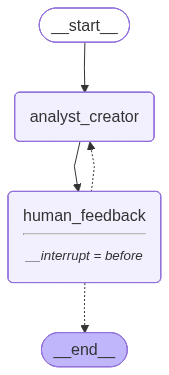

In [74]:
builder = StateGraph(OverallState)
builder.add_node("analyst_creator",analyst_creator)
builder.add_node("human_feedback",human_feedback)

builder.add_edge(START , "analyst_creator")
builder.add_edge("analyst_creator" , "human_feedback")
builder.add_conditional_edges("human_feedback",human_analyst_feedback , ['analyst_creator',END])

memory = MemorySaver()

graph = builder.compile(memory , interrupt_before = ['human_feedback'])

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [75]:
max_assistant = 3
topic = "why we require notebooks if we have laptops and tablets"
config = {'configurable':{'thread_id':2}}

for event in graph.stream({"topic":topic,"max_analyst":max_assistant},config ,
                          stream_mode="values"):
  print(event)

{'topic': 'why we require notebooks if we have laptops and tablets', 'max_analyst': 3}

{
    'topic': 'why we require notebooks if we have laptops and tablets',
    'max_analyst': 3,
    'analyst': [
        Analyst(
            name='Dr. Elizabeth Hartwell',
            affiliation='Institute for Technology and Learning',
            role='Educational Technologist',
            description='Dr. Hartwell focuses on the educational implications of technology. She is interested in 
how notebooks facilitate learning and creativity in ways that laptops and tablets may not. Her research often 
involves studies on student engagement and the role of traditional tools in modern education.'
        ),
        Analyst(
            name='Marcus Chen',
            affiliation='Ergonomics and Design Research Group',
            role='Ergonomics Specialist',
            description='Marcus Chen examines the physical and cognitive ergonomics of using different writing 
tools. He is particularly interested in the tactile feedback of notebooks and how it affects user comfort and 
productivity compared to digital devices. His work often informs product design and workplace ergonomics.'
        ),
        Analyst(
            name='Sophia Ramirez',
            affiliation='Digital Transformation Institute',
            role='Digital Transformation Analyst',
            description='Sophia Ramirez explores the broader impact of digital transformation on society. She is 
intrigued by the persistence of notebooks in an increasingly digital world and studies the cultural and 
psychological factors that drive this trend. Her work often involves surveys and interviews to understand user 
preferences and behaviors.'
        )
    ]
}

In [76]:
graph.get_state(config).next

('human_feedback',)

In [77]:
human_feedback = "Could you add more analyst from different fields also"
for event in graph.stream({"human_feedback":human_feedback},config ,
                          stream_mode="values"):
  print(event)

{
    'topic': 'why we require notebooks if we have laptops and tablets',
    'max_analyst': 3,
    'human_feedback': 'Could you add more analyst from different fields also',
    'analyst': [
        Analyst(
            name='Dr. Elizabeth Hartwell',
            affiliation='Institute for Technology and Learning',
            role='Educational Technologist',
            description='Dr. Hartwell focuses on the educational implications of technology. She is interested in 
how notebooks facilitate learning and creativity in ways that laptops and tablets may not. Her research often 
involves studies on student engagement and the role of traditional tools in modern education.'
        ),
        Analyst(
            name='Marcus Chen',
            affiliation='Ergonomics and Design Research Group',
            role='Ergonomics Specialist',
            description='Marcus Chen examines the physical and cognitive ergonomics of using different writing 
tools. He is particularly interested in the tactile feedback of notebooks and how it affects user comfort and 
productivity compared to digital devices. His work often informs product design and workplace ergonomics.'
        ),
        Analyst(
            name='Sophia Ramirez',
            affiliation='Digital Transformation Institute',
            role='Digital Transformation Analyst',
            description='Sophia Ramirez explores the broader impact of digital transformation on society. She is 
intrigued by the persistence of notebooks in an increasingly digital world and studies the cultural and 
psychological factors that drive this trend. Her work often involves surveys and interviews to understand user 
preferences and behaviors.'
        )
    ]
}

{
    'topic': 'why we require notebooks if we have laptops and tablets',
    'max_analyst': 3,
    'human_feedback': 'Could you add more analyst from different fields also',
    'analyst': [
        Analyst(
            name='Dr. Sarah Johnson',
            affiliation='Harvard University',
            role='Educational Technologist',
            description='Dr. Johnson specializes in the integration of technology in education. She is concerned 
with how different devices impact learning outcomes and is interested in understanding the unique benefits of 
notebooks in an era dominated by laptops and tablets.'
        ),
        Analyst(
            name='Alex Chen',
            affiliation='TechInsight Analytics',
            role='Market Analyst',
            description='Alex Chen focuses on consumer technology trends. He is intrigued by the market dynamics 
that keep notebooks relevant despite the rise of more advanced devices. His analysis often centers on consumer 
behavior and market demand.'
        ),
        Analyst(
            name='Dr. Emily Rodriguez',
            affiliation='Stanford University',
            role='Cognitive Psychologist',
            description='Dr. Rodriguez studies how different writing tools affect cognitive processes. She is 
particularly interested in the psychological aspects of notebook use, such as memory retention and idea generation,
compared to digital devices.'
        )
    ]
}

In [78]:
graph.get_state(config).next

('human_feedback',)

In [79]:
further_feedback = None

In [80]:
graph.update_state(config,{"human_feedback":further_feedback},as_node = 'human_feedback')

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f17dbf3-dcbe-6b23-8005-da283b5da27c'}}

In [81]:
graph.get_state(config).next

()

In [82]:
for event in graph.stream(None,config ,
                          stream_mode="updates"):
  print(event)

In [83]:
print(graph.get_state(config).next)

()

In [84]:
for analyst in graph.get_state(config).values.get('analyst'):
  print(f"Name :        {analyst.name}")
  print(f"Role :        {analyst.role}")
  print(f"Affiliation : {analyst.affiliation}")
  print(f"Description : {analyst.description}")
  print('-'*50)

Name :        Dr. Sarah Johnson

Role :        Educational Technologist

Affiliation : Harvard University

Description : Dr. Johnson specializes in the integration of technology in education. She is concerned with how 
different devices impact learning outcomes and is interested in understanding the unique benefits of notebooks in 
an era dominated by laptops and tablets.

--------------------------------------------------

...

Name :        Dr. Emily Rodriguez

Role :        Cognitive Psychologist

Affiliation : Stanford University

Description : Dr. Rodriguez studies how different writing tools affect cognitive processes. She is particularly 
interested in the psychological aspects of notebook use, such as memory retention and idea generation, compared to 
digital devices.

--------------------------------------------------

In [85]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic.

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.

2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}

Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.

When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

In [86]:
import operator
class State(MessagesState):
  analyst : Analyst
  context : Annotated[list, operator.add]
  interview : str
  section : list

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval.")

In [116]:
def create_question(state : State):
  analyst = state['analyst']
  message = state['messages']

  prompt = question_instructions.format(goals = analyst.persona)
  questions = llm.invoke([SystemMessage(content = prompt)]+message)

  return {'messages':[questions]}


In [88]:
from langchain_core.messages import get_buffer_string

# Search query writing
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert.

Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation.

First, analyze the full conversation.

Pay particular attention to the final question posed by the analyst.

Convert this final question into a well-structured web search query""")

In [89]:
def web_search(state : State):
  structure_llm = llm.with_structured_output(SearchQuery)
  search_query = structure_llm.invoke([search_instructions]+state['messages'])

  data = tavily.invoke({'query':search_query.search_query})
  search_docs = data.get("results",data)

  formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

  return {"context": [formatted_search_docs]}

In [90]:
def wiki_search(state: State):

    structure_llm = llm.with_structured_output(SearchQuery)
    search_query = structure_llm.invoke([search_instructions] + state['messages'])

    query_str = search_query.search_query.strip() if search_query.search_query else ""

    if not query_str:
        return {"context": ["<Document source='Wikipedia'>No search query generated.</Document>"]}

    search_docs = WikipediaLoader(query=query_str, load_max_docs=2).load()

    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata.get("source", "Wikipedia")}" title="{doc.metadata.get("title", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}


In [91]:
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}.

You goal is to answer a question posed by the interviewer.

To answer question, use this context:

{context}

When answering questions, follow these guidelines:

1. Use only the information provided in the context.

2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1].

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc

6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list:

[1] assistant/docs/llama3_1.pdf, page 7

And skip the addition of the brackets as well as the Document source preamble in your citation."""

In [92]:
def generate_answer(state : State):
  analyst = state['analyst']
  context = state['context']
  message = state['message']

  prompt = answer_instructions.format(goals = analyst.persona , context = context)
  answer = llm.invoke([SystemMessage(content = prompt)]+message)

  answer.name = 'expert'

  return {'messages':[answer]}

In [93]:
def save_interview(state : State):

  messages = state['messages']
  interview = get_buffer_string(messages)

  return {'interview':interview}

In [94]:
def route_messages(state:State , name : str = 'expert'):
  messages = state['messages']
  max_turns = state.get('max_num_turns',2)

  num_response = len([m for m in messages if isinstance(m,AIMessage) and m.name == name])

  if num_response >= max_turns:
    return 'save_interview'

  last_question = messages[-2]

  if "Thank you so much for your help!" in last_question.content:
    return 'save_interview'

  return 'ask_question'

In [95]:
section_writer_instructions = """You are an expert technical writer.

Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents:
- The name of each source document is at the start of the document, with the <Document tag.

2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers

3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst:
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents

6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/

8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

In [96]:
def write_section(state:State):

  interview = state['interview']
  analyst = state['analyst']
  context = state['context']

  system_message = section_writer_instructions.format(focus = analyst.description)

  section = llm.invoke([SystemMessage(content = system_message)]+context+[HumanMessage(content = interview)])

  return {'section':[section.content]}


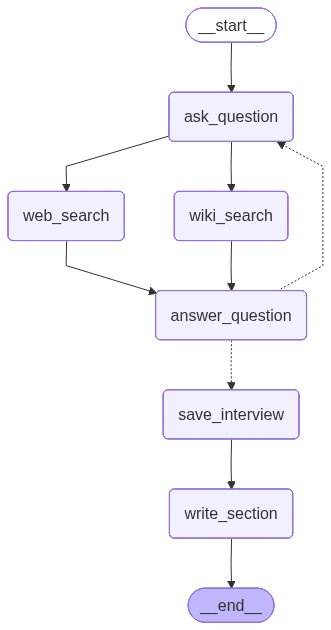

In [117]:
subbuilder = StateGraph(State)
subbuilder.add_node('ask_question',create_question)
subbuilder.add_node('web_search',web_search)
subbuilder.add_node('wiki_search',wiki_search)
subbuilder.add_node('answer_question',generate_answer)
subbuilder.add_node('save_interview',save_interview)
subbuilder.add_node('write_section',write_section)

subbuilder.add_edge(START , 'ask_question')
subbuilder.add_edge('ask_question' , 'web_search')
subbuilder.add_edge('ask_question' , 'wiki_search')
subbuilder.add_edge('web_search' , 'answer_question')
subbuilder.add_edge('wiki_search' , 'answer_question')
subbuilder.add_conditional_edges('answer_question',route_messages,['ask_question' , 'save_interview'])
subbuilder.add_edge('save_interview' , 'write_section')
subbuilder.add_edge('write_section' , END)

memory = MemorySaver()

graph1 = subbuilder.compile(memory)

display(Image(graph1.get_graph(xray=1).draw_mermaid_png()))

In [118]:
analyst = graph.get_state(config).values.get('analyst')

In [119]:
analyst[0]

Analyst(name='Dr. Sarah Johnson', affiliation='Harvard University', role='Educational Technologist', description='Dr. Johnson specializes in the integration of technology in education. She is concerned with how different devices impact learning outcomes and is interested in understanding the unique benefits of notebooks in an era dominated by laptops and tablets.')

In [120]:
from IPython.display import Markdown
messages = [HumanMessage(f"So you said you were writing an article on {topic}?")]
thread = {"configurable": {"thread_id": "1"}}
interview = graph1.invoke({"analyst": analyst[0], "messages": messages, "max_num_turns": 2}, thread)
Markdown(interview['sections'][0])

HTTPStatusError: Error response 400 while fetching https://api.mistral.ai/v1/chat/completions: {"object":"error","message":"Expected last role User or Tool (or Assistant with prefix True) for serving but got assistant","type":"invalid_request_message_order","param":null,"code":"3230","raw_status_code":400}